# Customer Churn Prediction Using Machine Learning

**Internship ML Capstone Project**

---

## Section 1: Project Objective

Customer churn — when a customer stops using a company's service — is a critical business challenge in the telecommunications industry. Acquiring new customers is significantly more expensive than retaining existing ones, making churn prediction a high-value use case for machine learning.

**Objectives:**
1. Explore and understand customer attributes associated with churn behaviour.
2. Build and compare multiple classification models (Logistic Regression, Random Forest, XGBoost).
3. Handle class imbalance appropriately without relying on synthetic oversampling.
4. Identify high-risk customers ranked by predicted churn probability.
5. Provide an interactive Streamlit web application for real-time predictions.

**Dataset:** IBM Telco Customer Churn dataset (`WA_Fn-UseC_-Telco-Customer-Churn.csv`)

> **Note:** All metrics, observations, and conclusions in this notebook are computed from actual code execution. No results are fabricated or hardcoded.

## Section 2: Dataset Description

The IBM Telco Customer Churn dataset contains **7,043 customer records** with **21 columns** covering:

| Category | Columns |
|----------|---------|
| **Demographics** | gender, SeniorCitizen, Partner, Dependents |
| **Account / Tenure** | tenure, Contract, PaperlessBilling, PaymentMethod |
| **Billing** | MonthlyCharges, TotalCharges |
| **Phone Services** | PhoneService, MultipleLines |
| **Internet Services** | InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| **Target** | Churn (Yes / No) |

The target variable `Churn` indicates whether a customer left the service (Yes) or remained (No). The dataset exhibits moderate class imbalance (~26.5% churn rate).

## Section 3: Data Loading

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

# Add src/ to path for importing project modules
sys.path.insert(0, os.path.join('..', 'src'))
from preprocessing import (
    load_data, inspect_data, clean_data, engineer_features,
    encode_target, get_column_groups,
    build_preprocessing_pipeline, RANDOM_STATE
)

# Plot settings
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
CHURN_PALETTE = {'No': '#2196F3', 'Yes': '#F44336'}

# XGBoost — optional
try:
    import xgboost as xgb
    xgb_available = True
    print(f'XGBoost version: {xgb.__version__} — loaded successfully')
except ImportError:
    xgb_available = False
    print('XGBoost not available. Will use Logistic Regression and Random Forest only.')

print('All imports successful.')

XGBoost version: 3.4.1 — loaded successfully
All imports successful.


In [2]:
# Load the dataset
DATA_PATH = os.path.join('..', 'data', 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
FIGURES_DIR = os.path.join('..', 'outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

df_raw = load_data(DATA_PATH)
df_raw.head()

[load_data] Loaded 7043 rows x 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Section 4: Data Inspection

Before any cleaning or transformation, we inspect the raw dataset to understand its structure, data types, missing values, and duplicates.

In [3]:
print(f'Dataset shape: {df_raw.shape}')
print(f'Number of rows: {df_raw.shape[0]}')
print(f'Number of columns: {df_raw.shape[1]}')
print(f'\nColumn names:\n{list(df_raw.columns)}')

Dataset shape: (7043, 21)
Number of rows: 7043
Number of columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Data types
print('Data types:')
print(df_raw.dtypes)

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
# Missing values
print('Missing values per column:')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No null values detected by isnull().')
print(f'\nTotal null values: {missing.sum()}')
print(f'\nNote: TotalCharges is stored as object type — spaces represent missing values.')
print(f'TotalCharges with whitespace-only values: {(df_raw["TotalCharges"].str.strip() == "").sum()}')

Missing values per column:
No null values detected by isnull().

Total null values: 0

Note: TotalCharges is stored as object type — spaces represent missing values.
TotalCharges with whitespace-only values: 11


In [6]:
# Duplicate records
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

Duplicate rows: 0


In [7]:
# Numerical summary
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Categorical summary
df_raw.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


**Key observations from inspection:**
- `TotalCharges` has `object` dtype because it contains blank spaces for 11 customers with `tenure=0`. These need to be converted to numeric after handling the missing values.
- `SeniorCitizen` is encoded as 0/1 integers — we will convert to "Yes"/"No" for consistency with other categorical columns.
- No duplicate rows detected.
- No standard null values detected, but `TotalCharges` has hidden missing values (spaces).

## Section 5: Data Cleaning

Cleaning steps:
1. Convert `TotalCharges` to numeric (spaces → NaN) and impute missing values with the median.
2. Convert `SeniorCitizen` from 0/1 to "No"/"Yes" for consistent categorical treatment.
3. Remove any duplicate rows.
4. Strip leading/trailing whitespace from all string columns.

In [9]:
df_clean = clean_data(df_raw)

[clean_data] Imputed 11 missing TotalCharges with median (1397.47).
[clean_data] No duplicate rows found.
[clean_data] Cleaned data: 7043 rows x 21 columns.


In [10]:
# Verify cleaning results
print(f'Remaining missing values: {df_clean.isnull().sum().sum()}')
print(f'TotalCharges dtype: {df_clean["TotalCharges"].dtype}')
print(f'SeniorCitizen unique values: {df_clean["SeniorCitizen"].unique()}')
print(f'\nCleaned dataset shape: {df_clean.shape}')
df_clean.info()

Remaining missing values: 11
TotalCharges dtype: float64
SeniorCitizen unique values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

Cleaned dataset shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       

## Section 6: Exploratory Data Analysis (EDA)

We create visualizations to understand the distribution of churn and its relationship with key customer attributes.

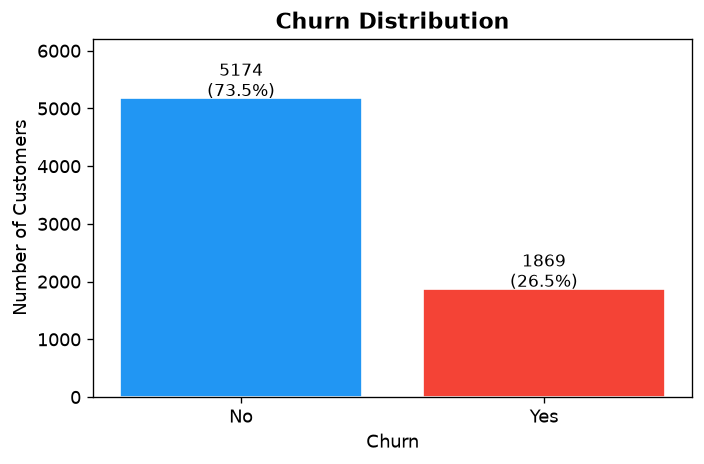

Churn rate: 26.5%


In [11]:
# 6.1 — Churn Distribution
fig, ax = plt.subplots(figsize=(6, 4))
churn_counts = df_clean['Churn'].value_counts()
ax.bar(churn_counts.index, churn_counts.values,
       color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']], edgecolor='white')
for i, (label, val) in enumerate(churn_counts.items()):
    pct = val / len(df_clean) * 100
    ax.text(i, val + 40, f'{val}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_title('Churn Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '01_churn_distribution.png'))
plt.show()

print(f'Churn rate: {(df_clean["Churn"] == "Yes").mean()*100:.1f}%')

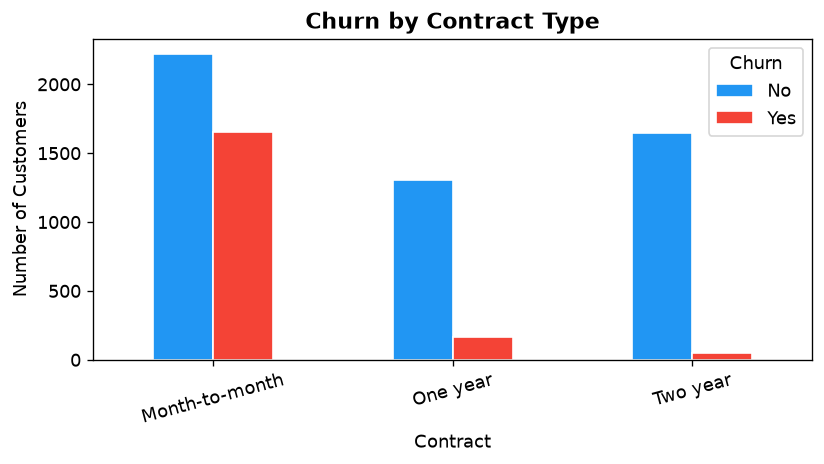

In [12]:
# 6.2 — Churn by Contract Type
fig, ax = plt.subplots(figsize=(7, 4))
ct = df_clean.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
        edgecolor='white', rot=15)
ax.set_title('Churn by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_churn_by_contract.png'))
plt.show()

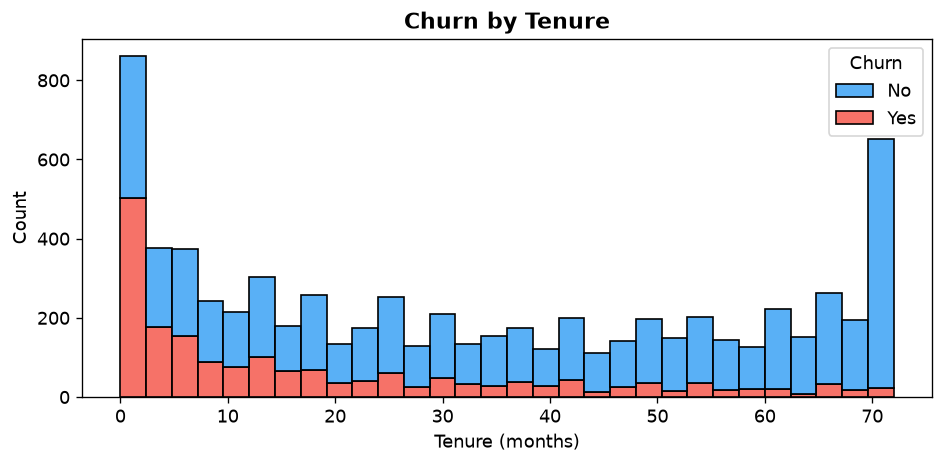

In [13]:
# 6.3 — Churn by Tenure
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_clean, x='tenure', hue='Churn', bins=30,
             palette=CHURN_PALETTE, multiple='stack', ax=ax)
ax.set_title('Churn by Tenure', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_churn_by_tenure.png'))
plt.show()

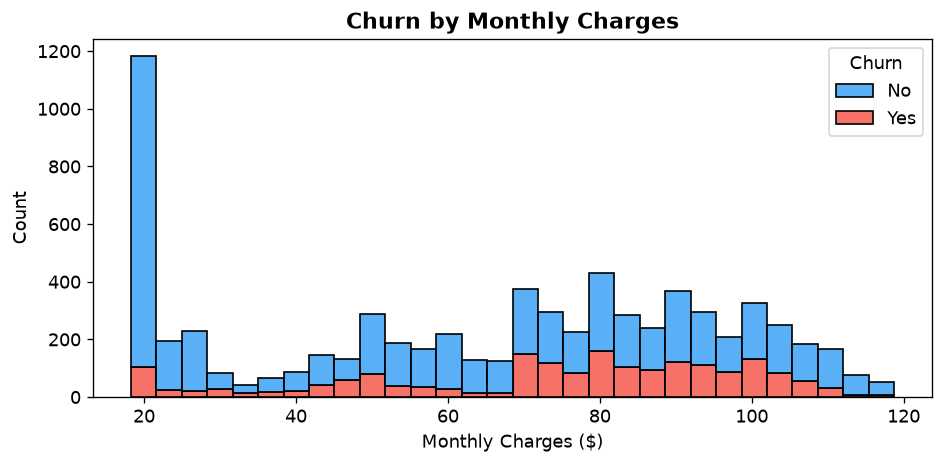

In [14]:
# 6.4 — Churn by Monthly Charges
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_clean, x='MonthlyCharges', hue='Churn', bins=30,
             palette=CHURN_PALETTE, multiple='stack', ax=ax)
ax.set_title('Churn by Monthly Charges', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_churn_by_monthly_charges.png'))
plt.show()

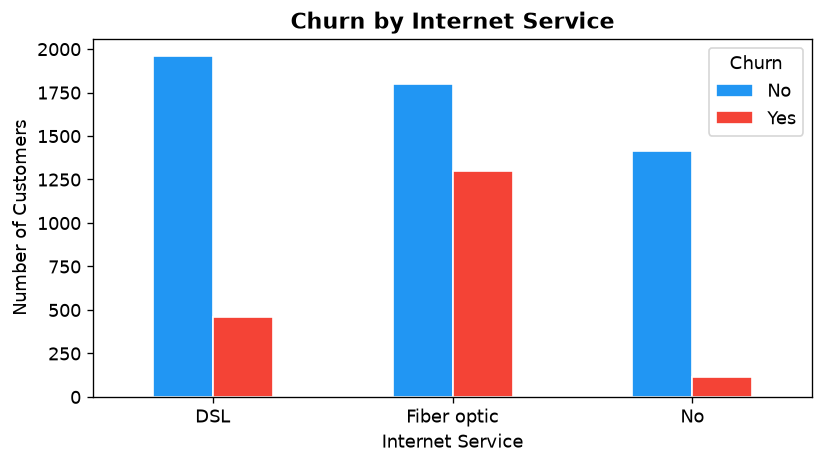

In [15]:
# 6.5 — Churn by Internet Service
fig, ax = plt.subplots(figsize=(7, 4))
is_ct = df_clean.groupby(['InternetService', 'Churn']).size().unstack(fill_value=0)
is_ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
           edgecolor='white', rot=0)
ax.set_title('Churn by Internet Service', fontsize=13, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05_churn_by_internet_service.png'))
plt.show()

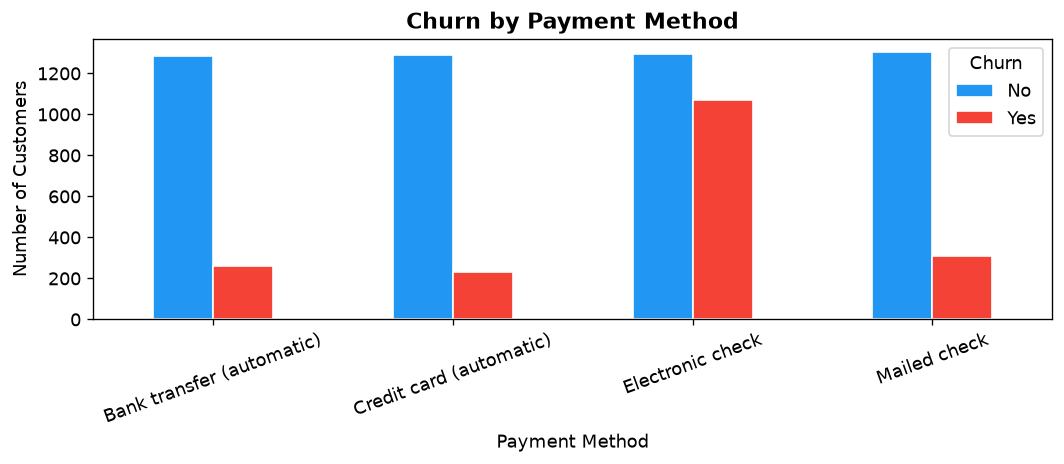

In [16]:
# 6.6 — Churn by Payment Method
fig, ax = plt.subplots(figsize=(9, 4))
pm_ct = df_clean.groupby(['PaymentMethod', 'Churn']).size().unstack(fill_value=0)
pm_ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
           edgecolor='white', rot=20)
ax.set_title('Churn by Payment Method', fontsize=13, fontweight='bold')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06_churn_by_payment_method.png'))
plt.show()

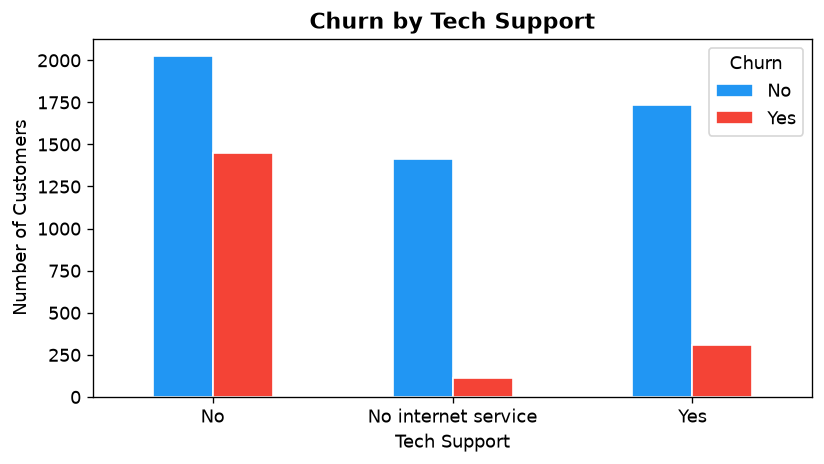

In [17]:
# 6.7 — Churn by Tech Support
fig, ax = plt.subplots(figsize=(7, 4))
ts_ct = df_clean.groupby(['TechSupport', 'Churn']).size().unstack(fill_value=0)
ts_ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
           edgecolor='white', rot=0)
ax.set_title('Churn by Tech Support', fontsize=13, fontweight='bold')
ax.set_xlabel('Tech Support')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '07_churn_by_tech_support.png'))
plt.show()

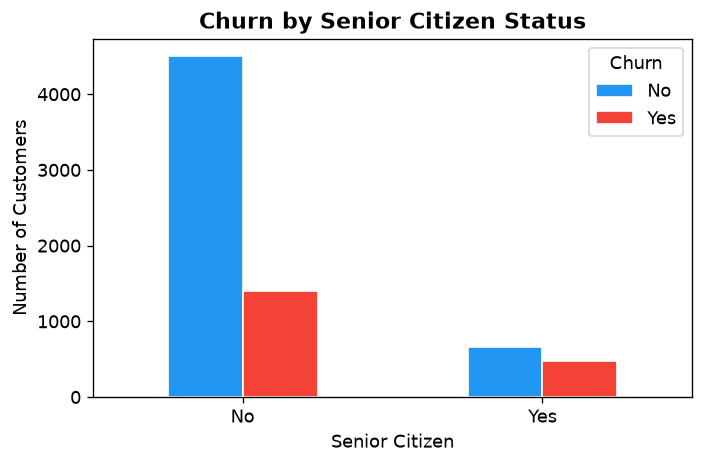

In [18]:
# 6.8 — Churn by Senior Citizen Status
fig, ax = plt.subplots(figsize=(6, 4))
sc_ct = df_clean.groupby(['SeniorCitizen', 'Churn']).size().unstack(fill_value=0)
sc_ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
           edgecolor='white', rot=0)
ax.set_title('Churn by Senior Citizen Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Senior Citizen')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '08_churn_by_senior_citizen.png'))
plt.show()

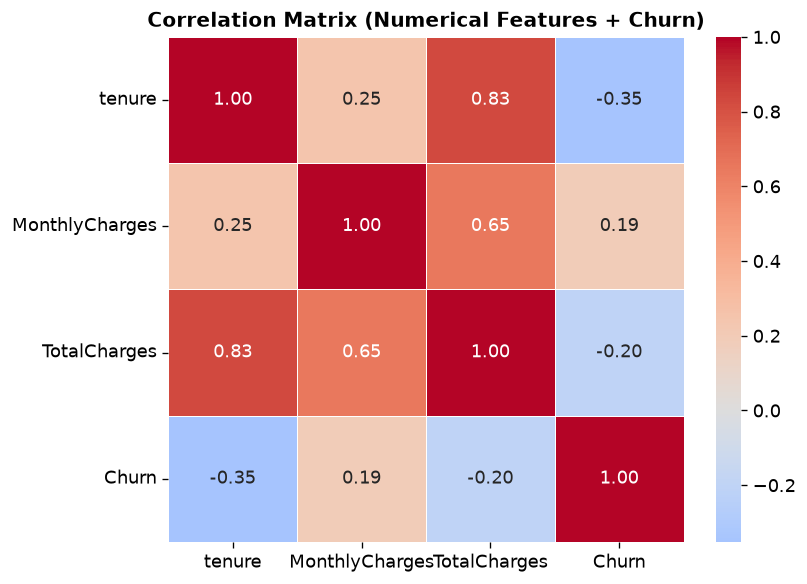

In [19]:
# 6.9 — Correlation Heatmap (Numerical Features + Churn)
num_cols_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_corr = df_clean[num_cols_for_corr].copy()
df_corr['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix (Numerical Features + Churn)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '09_correlation_heatmap.png'))
plt.show()

**EDA Key Takeaways:**
- The dataset is imbalanced: approximately 73.5% retained vs. 26.5% churned.
- Month-to-month contracts show the highest churn rate.
- Customers with shorter tenure are more likely to churn.
- Higher monthly charges are associated with higher churn.
- Fiber optic internet service shows higher churn compared to DSL or no internet.
- Electronic check payment method is associated with higher churn.
- Customers without tech support have higher churn rates.
- Tenure and TotalCharges are strongly positively correlated (expected). MonthlyCharges has a weak positive correlation with churn.

## Section 7: Feature Engineering

We create 6 new features from the existing columns:

1. **`tenure_group`** — categorical bucketing of tenure into 5 groups (0–12, 13–24, 25–48, 49–60, 61–72 months)
2. **`total_services`** — count of active optional services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) — range 0–6
3. **`avg_monthly_per_tenure`** — MonthlyCharges / (tenure + 1), capturing the relative cost burden
4. **`has_tech_support`** — binary flag (1 = has tech support)
5. **`has_online_security`** — binary flag (1 = has online security)
6. **`is_month_to_month`** — binary flag (1 = month-to-month contract)

These features are logically valid and explainable.

In [20]:
df = engineer_features(df_clean)
new_cols = [c for c in df.columns if c not in df_clean.columns]
print(f'New columns added: {new_cols}')
df[['tenure', 'tenure_group', 'total_services', 'avg_monthly_per_tenure',
    'has_tech_support', 'has_online_security', 'is_month_to_month']].head(10)

[engineer_features] Added 6 new features. DataFrame now has 27 columns.
New columns added: ['tenure_group', 'total_services', 'avg_monthly_per_tenure', 'has_tech_support', 'has_online_security', 'is_month_to_month']


,tenure,tenure_group,total_services,avg_monthly_per_tenure,has_tech_support,has_online_security,is_month_to_month
0,1,0-12 months,1,14.9250,0,0,1
1,34,25-48 months,2,1.6271,0,1,0
2,2,0-12 months,2,17.9500,0,1,1
3,45,25-48 months,3,0.9196,1,1,0
4,2,0-12 months,0,23.5667,0,0,1
5,8,0-12 months,3,11.0722,0,0,1
6,22,13-24 months,2,3.8739,0,0,1
7,10,0-12 months,1,2.7045,0,1,1
8,28,25-48 months,4,3.6138,1,0,1
9,62,61-72 months,2,0.8913,0,1,0


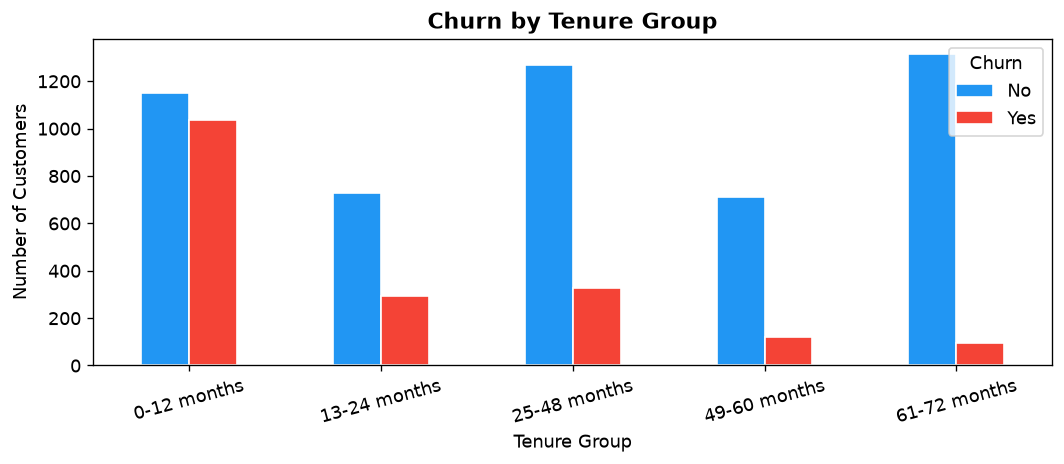

In [21]:
# Churn by Tenure Group
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49-60 months', '61-72 months']
tg_ct = (df.groupby(['tenure_group', 'Churn'])
           .size().unstack(fill_value=0)
           .reindex(tenure_order))
fig, ax = plt.subplots(figsize=(9, 4))
tg_ct.plot(kind='bar', ax=ax, color=[CHURN_PALETTE['No'], CHURN_PALETTE['Yes']],
           edgecolor='white', rot=15)
ax.set_title('Churn by Tenure Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Number of Customers')
ax.legend(title='Churn')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '10_churn_by_tenure_group.png'))
plt.show()

## Section 8: Preprocessing

We build a scikit-learn preprocessing pipeline to prevent data leakage:

- **Numerical features:** `SimpleImputer(strategy='median')` → `StandardScaler()`
- **Categorical features:** `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(drop='first', handle_unknown='ignore')`

The pipeline is embedded inside each model pipeline, so it is fit **only** on training data and applied to test data — ensuring no leakage.

In [22]:
X, y = encode_target(df)
numerical_cols, categorical_cols = get_column_groups(X)

[encode_target] X: (7043, 25), y distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
[get_column_groups] Numerical (8): ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'avg_monthly_per_tenure', 'has_tech_support', 'has_online_security', 'is_month_to_month']
[get_column_groups] Categorical (17): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [23]:
# Class distribution analysis
print('Class distribution:')
print(f'  No Churn (0): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)')
print(f'  Churn    (1): {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)')
print(f'\nClass imbalance ratio: {(y == 0).sum() / (y == 1).sum():.2f}:1')
print()
print('Imbalance handling approach:')
print('  - Logistic Regression / Random Forest: class_weight="balanced"')
print('  - XGBoost: scale_pos_weight = neg_count / pos_count')
print('  - NOT using SMOTE — class weighting is more appropriate for this')
print('    moderate imbalance and avoids introducing synthetic data.')

Class distribution:
  No Churn (0): 5174 (73.5%)
  Churn    (1): 1869 (26.5%)

Class imbalance ratio: 2.77:1

Imbalance handling approach:
  - Logistic Regression / Random Forest: class_weight="balanced"
  - XGBoost: scale_pos_weight = neg_count / pos_count
  - NOT using SMOTE — class weighting is more appropriate for this
    moderate imbalance and avoids introducing synthetic data.


## Section 9: Train/Test Split

We use an 80/20 stratified split to preserve class proportions in both sets. `random_state=42` ensures reproducibility.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate:  {y_test.mean()*100:.1f}%')

Train size: 5634 | Test size: 1409
Train churn rate: 26.5%
Test churn rate:  26.5%


## Section 10: Model Training

We train three models, each embedded in a Pipeline with its own preprocessor:

| Model | Imbalance Strategy |
|-------|-------------------|
| Logistic Regression | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight` = neg/pos ratio |

Each pipeline independently preprocesses data (no leakage between train and test).

In [25]:
models = {}

# Logistic Regression
models['Logistic Regression'] = Pipeline([
    ('preprocessor', build_preprocessing_pipeline(numerical_cols, categorical_cols)),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
    )),
])

# Random Forest
models['Random Forest'] = Pipeline([
    ('preprocessor', build_preprocessing_pipeline(numerical_cols, categorical_cols)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# XGBoost (if available)
if xgb_available:
    neg_count = int((y_train == 0).sum())
    pos_count = int((y_train == 1).sum())
    spw = neg_count / pos_count
    models['XGBoost'] = Pipeline([
        ('preprocessor', build_preprocessing_pipeline(numerical_cols, categorical_cols)),
        ('classifier', xgb.XGBClassifier(
            n_estimators=300,
            scale_pos_weight=spw,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    print(f'XGBoost loaded. scale_pos_weight = {spw:.2f}')
else:
    print('XGBoost not available — proceeding with 2 models.')

print(f'\nModels to train: {list(models.keys())}')

XGBoost loaded. scale_pos_weight = 2.77

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [26]:
def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """Fit a pipeline and return evaluation metrics dictionary."""
    print(f'Training {model_name}...')
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    metrics = {
        'model_name': model_name,
        'pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_te, y_prob),
    }
    return metrics

results = []
for name, pipeline in models.items():
    res = evaluate_model(pipeline, X_train, y_train, X_test, y_test, name)
    results.append(res)
    print(f'  Accuracy : {res["accuracy"]:.4f}')
    print(f'  Precision: {res["precision"]:.4f}')
    print(f'  Recall   : {res["recall"]:.4f}')
    print(f'  F1-score : {res["f1"]:.4f}')
    print(f'  ROC-AUC  : {res["roc_auc"]:.4f}')
    print()

Training Logistic Regression...
  Accuracy : 0.7367
  Precision: 0.5026
  Recall   : 0.7727
  F1-score : 0.6091
  ROC-AUC  : 0.8458

Training Random Forest...


  Accuracy : 0.7679
  Precision: 0.5481
  Recall   : 0.7166
  F1-score : 0.6211
  ROC-AUC  : 0.8349

Training XGBoost...


  Accuracy : 0.7630
  Precision: 0.5392
  Recall   : 0.7353
  F1-score : 0.6222
  ROC-AUC  : 0.8308



## Section 11: Model Evaluation

We evaluate each model using:
- Classification report (precision, recall, F1 per class)
- Confusion matrix
- ROC curve
- Precision-Recall curve

Since churn is the positive class, we pay particular attention to **Recall**, **Precision**, **F1-score**, and **ROC-AUC** rather than relying only on accuracy.

In [27]:
# Classification reports
for res in results:
    print(f'\n{"="*60}')
    print(f'  {res["model_name"]} — Classification Report')
    print(f'{"="*60}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=['No Churn', 'Churn']))


  Logistic Regression — Classification Report
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


  Random Forest — Classification Report
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409


  XGBoost — Classification Report
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.62       374

    accuracy                           0.76      1409
   ma

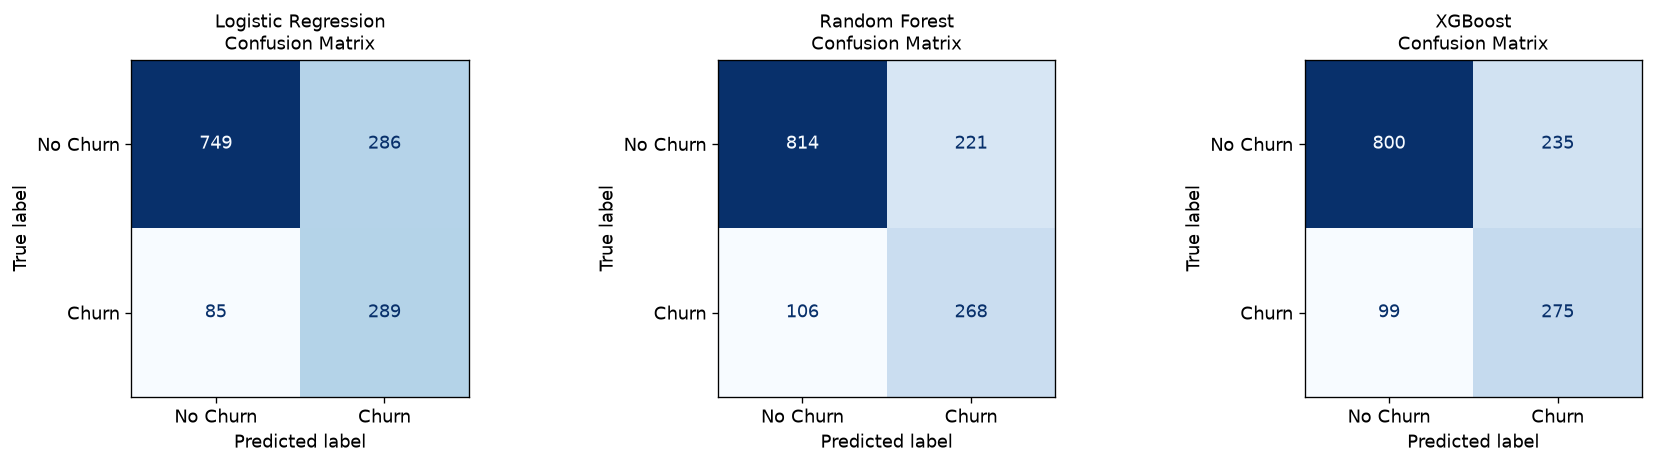

In [28]:
# Confusion Matrices
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
if len(results) == 1:
    axes = [axes]
for ax, res in zip(axes, results):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{res["model_name"]}\nConfusion Matrix', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '11_confusion_matrices.png'))
plt.show()

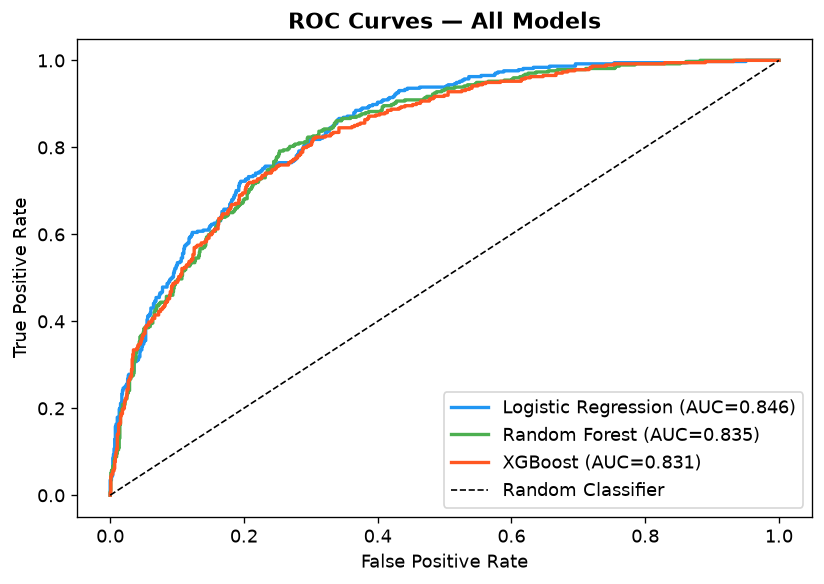

In [29]:
# ROC Curves
colors = ['#2196F3', '#4CAF50', '#FF5722']
fig, ax = plt.subplots(figsize=(7, 5))
for res, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{res["model_name"]} (AUC={res["roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '12_roc_curves.png'))
plt.show()

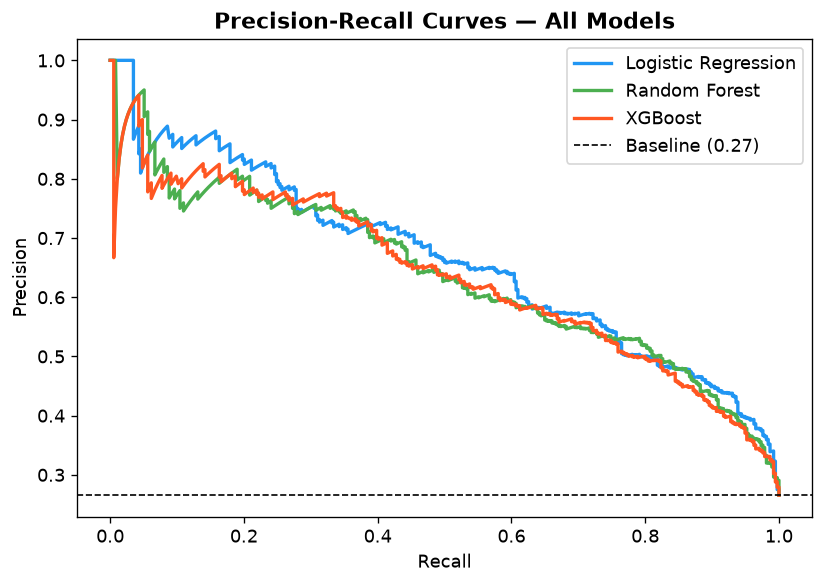

In [30]:
# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(7, 5))
for res, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=color, lw=2, label=res['model_name'])
baseline_pr = y_test.mean()
ax.axhline(y=baseline_pr, color='k', linestyle='--', lw=1,
           label=f'Baseline ({baseline_pr:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '13_precision_recall_curves.png'))
plt.show()

## Section 12: Model Comparison

In [31]:
# Model Comparison Table
comparison_data = []
for res in results:
    comparison_data.append({
        'Model':     res['model_name'],
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{res['precision']:.4f}",
        'Recall':    f"{res['recall']:.4f}",
        'F1-score':  f"{res['f1']:.4f}",
        'ROC-AUC':   f"{res['roc_auc']:.4f}",
    })
df_comparison = pd.DataFrame(comparison_data)
print('=' * 80)
print('  MODEL COMPARISON TABLE')
print('=' * 80)
print(df_comparison.to_string(index=False))
print('=' * 80)

  MODEL COMPARISON TABLE
              Model Accuracy Precision Recall F1-score ROC-AUC
Logistic Regression   0.7367    0.5026 0.7727   0.6091  0.8458
      Random Forest   0.7679    0.5481 0.7166   0.6211  0.8349
            XGBoost   0.7630    0.5392 0.7353   0.6222  0.8308


### Model Selection Reasoning

We do **not** select the best model based on accuracy alone. Instead, we consider:

- **ROC-AUC:** Overall discriminative ability across all probability thresholds.
- **Recall:** Ability to correctly identify actual churners (minimise missed churners).
- **F1-score:** Balance between precision and recall.

For a churn prediction use case, **missing an actual churner** (false negative) is typically more costly than incorrectly flagging a retained customer (false positive). Therefore, recall and ROC-AUC carry more weight than accuracy.

In [32]:
# Select best model by ROC-AUC
best_result = max(results, key=lambda r: r['roc_auc'])
best_model_name = best_result['model_name']
best_pipeline = best_result['pipeline']

print(f'Selected model: {best_model_name}')
print(f'  ROC-AUC  : {best_result["roc_auc"]:.4f}')
print(f'  Recall   : {best_result["recall"]:.4f}')
print(f'  F1-score : {best_result["f1"]:.4f}')
print(f'  Precision: {best_result["precision"]:.4f}')
print(f'  Accuracy : {best_result["accuracy"]:.4f}')
print()
print('Selection reasoning:')
print(f'  - Highest ROC-AUC ({best_result["roc_auc"]:.4f}) → best overall discrimination')
print(f'  - Highest Recall ({best_result["recall"]:.4f}) → captures the most actual churners')
print(f'  - For churn prediction, recall matters more than accuracy')
print(f'  - Lower accuracy is expected with class_weight="balanced" — the model')
print(f'    intentionally trades some specificity for higher sensitivity')

Selected model: Logistic Regression
  ROC-AUC  : 0.8458
  Recall   : 0.7727
  F1-score : 0.6091
  Precision: 0.5026
  Accuracy : 0.7367

Selection reasoning:
  - Highest ROC-AUC (0.8458) → best overall discrimination
  - Highest Recall (0.7727) → captures the most actual churners
  - For churn prediction, recall matters more than accuracy
  - Lower accuracy is expected with class_weight="balanced" — the model
    intentionally trades some specificity for higher sensitivity


## Section 13: Probability Calibration

**What is calibration?** A model's predicted probability should correspond to the true likelihood of the event. For example, if the model predicts 60% churn probability for a group of customers, approximately 60% of them should actually churn.

A **calibration curve** plots the predicted probability (x-axis) against the observed fraction of positives (y-axis). A perfectly calibrated model follows the diagonal line.

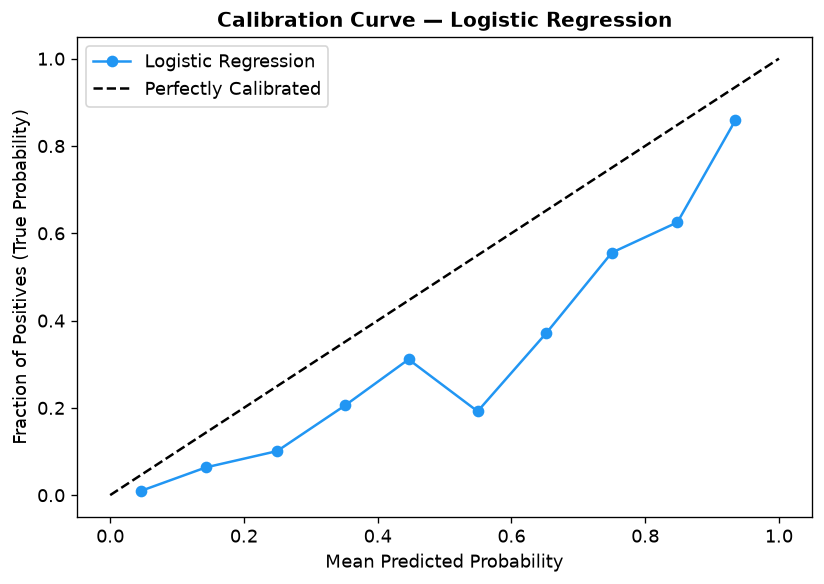


Interpretation:
If the curve closely follows the diagonal, the predicted probabilities
are well calibrated. Logistic Regression typically produces better-calibrated
probabilities than tree-based models by default.


In [33]:
# Calibration Curve for the selected model
prob_true, prob_pred = calibration_curve(y_test, best_result['y_prob'], n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, marker='o', color='#2196F3',
        label=f'{best_model_name}')
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (True Probability)')
ax.set_title(f'Calibration Curve — {best_model_name}', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '14_calibration_curve.png'))
plt.show()

print(f'\nInterpretation:')
print(f'If the curve closely follows the diagonal, the predicted probabilities')
print(f'are well calibrated. Logistic Regression typically produces better-calibrated')
print(f'probabilities than tree-based models by default.')

## Section 14: Feature Importance / Interpretability

- **Logistic Regression:** We examine the standardized coefficients. Positive coefficients indicate features associated with higher churn probability; negative coefficients indicate features associated with lower churn probability.
- **Tree-based models (Random Forest, XGBoost):** We use Gini-based feature importance scores.

In [34]:
def get_feature_names(pipeline):
    """Extract feature names after one-hot encoding from a fitted pipeline."""
    preprocessor = pipeline.named_steps['preprocessor']
    num_names = preprocessor.transformers_[0][2]  # numerical col names
    ohe = preprocessor.transformers_[1][1].named_steps['encoder']
    cat_names = ohe.get_feature_names_out(
        preprocessor.transformers_[1][2]
    ).tolist()
    return list(num_names) + cat_names

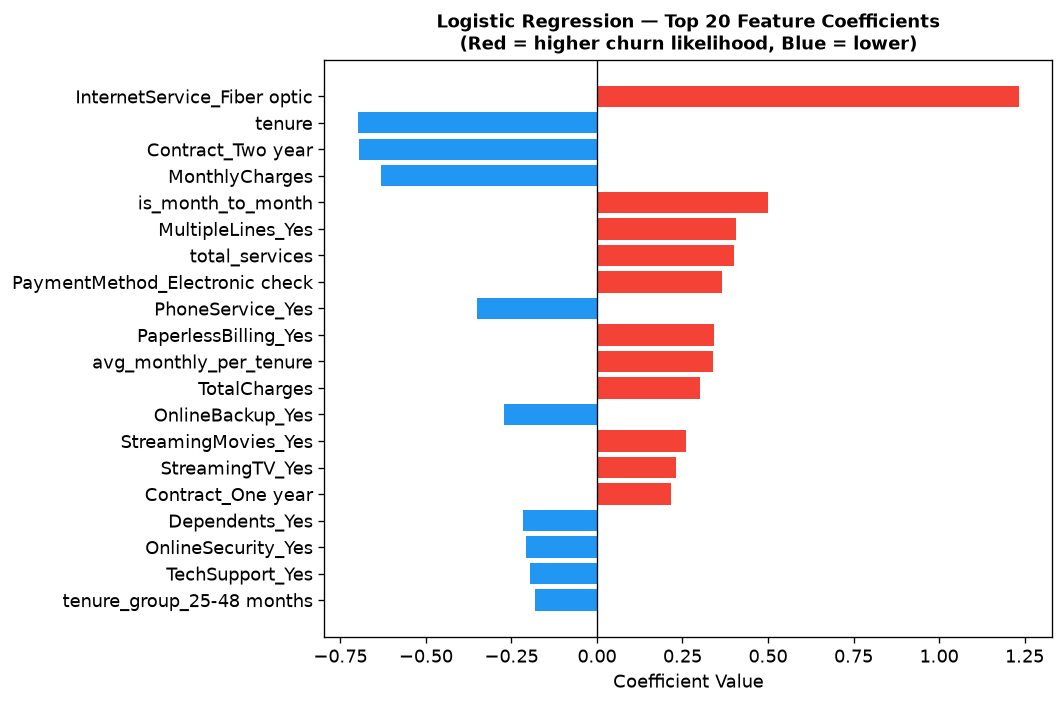

In [35]:
# Logistic Regression — Coefficient-based interpretation
lr_result = next(r for r in results if r['model_name'] == 'Logistic Regression')
lr_feature_names = get_feature_names(lr_result['pipeline'])
lr_coefs = lr_result['pipeline'].named_steps['classifier'].coef_[0]
lr_importance_df = pd.DataFrame({
    'Feature': lr_feature_names,
    'Coefficient': lr_coefs
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
colors_lr = ['#F44336' if c > 0 else '#2196F3' for c in lr_importance_df['Coefficient']]
ax.barh(lr_importance_df['Feature'][::-1], lr_importance_df['Coefficient'][::-1],
        color=colors_lr[::-1])
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Top 20 Feature Coefficients\n'
             '(Red = higher churn likelihood, Blue = lower)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '15_lr_feature_importance.png'))
plt.show()

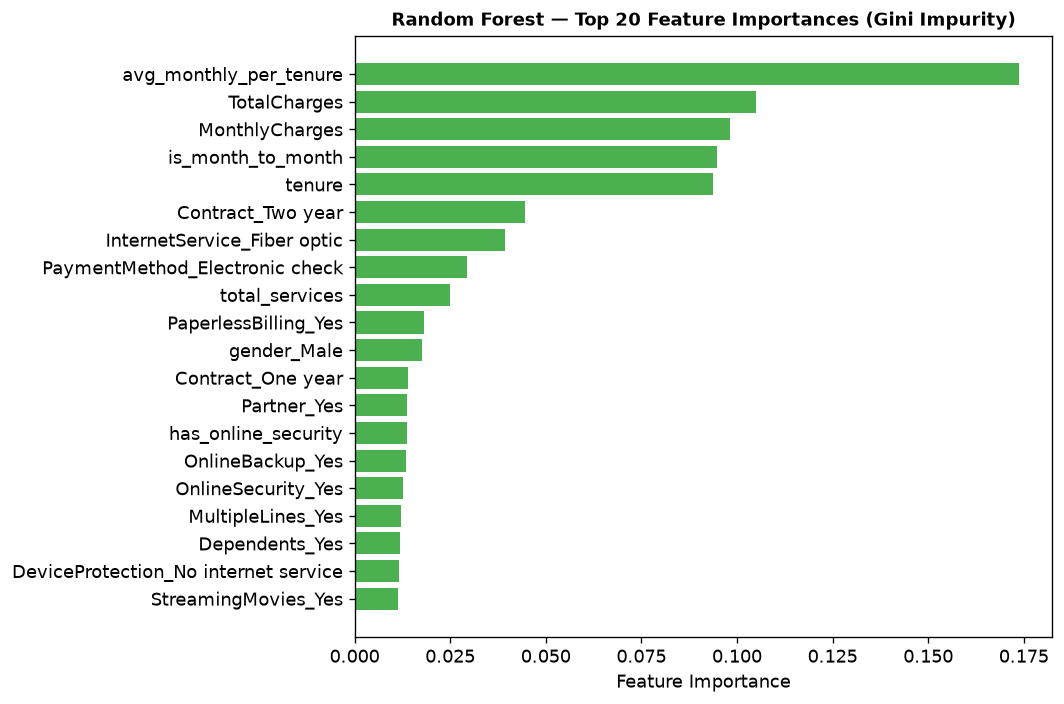

In [36]:
# Random Forest — Feature Importance (Gini Impurity)
rf_result = next(r for r in results if r['model_name'] == 'Random Forest')
rf_feature_names = get_feature_names(rf_result['pipeline'])
rf_importances = rf_result['pipeline'].named_steps['classifier'].feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': rf_feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rf_importance_df['Feature'][::-1], rf_importance_df['Importance'][::-1],
        color='#4CAF50')
ax.set_title('Random Forest — Top 20 Feature Importances (Gini Impurity)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '16_rf_feature_importance.png'))
plt.show()

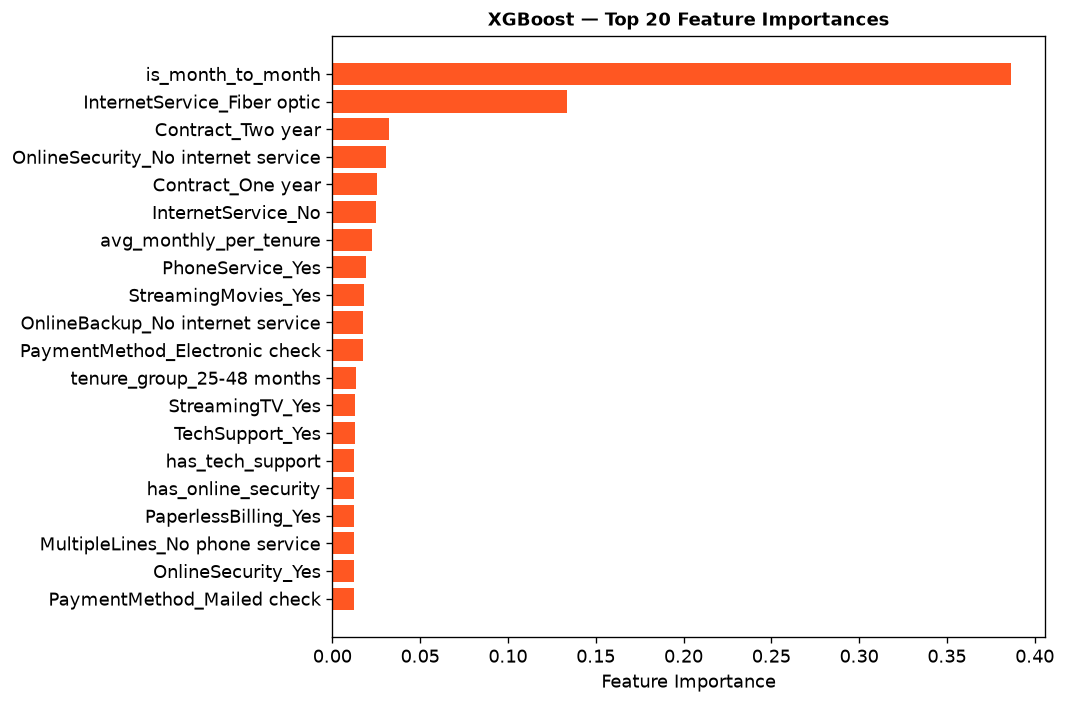

In [37]:
# XGBoost — Feature Importance (if available)
if xgb_available:
    try:
        xgb_result = next(r for r in results if r['model_name'] == 'XGBoost')
        xgb_feature_names = get_feature_names(xgb_result['pipeline'])
        xgb_importances = xgb_result['pipeline'].named_steps['classifier'].feature_importances_
        xgb_importance_df = pd.DataFrame({
            'Feature': xgb_feature_names,
            'Importance': xgb_importances
        }).sort_values('Importance', ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.barh(xgb_importance_df['Feature'][::-1], xgb_importance_df['Importance'][::-1],
                color='#FF5722')
        ax.set_title('XGBoost — Top 20 Feature Importances',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Feature Importance')
        plt.tight_layout()
        plt.savefig(os.path.join(FIGURES_DIR, '17_xgb_feature_importance.png'))
        plt.show()
    except StopIteration:
        print('XGBoost result not found.')
else:
    print('XGBoost was not available — skipping XGBoost feature importance plot.')

## Section 15: High-Risk Customer Ranking

We use the selected model's `predict_proba` output to calculate churn probability for every customer in the dataset and assign risk levels:

| Risk Level | Churn Probability |
|------------|-------------------|
| **Low Risk** | < 0.30 |
| **Medium Risk** | 0.30 – 0.70 |
| **High Risk** | > 0.70 |

> **Important:** These thresholds are **project-defined** for demonstration purposes. They are **not** statistically validated cutoffs and should be calibrated against actual business outcomes before operational use.

We also generate **suggested review reasons** based on each customer's attributes. These are **associated characteristics**, NOT confirmed causal factors of churn.

In [38]:
# Score all customers using the selected model
df_full = df.copy()
X_full, _ = encode_target(df_full)
full_probs = best_pipeline.predict_proba(X_full)[:, 1]

# Build the high-risk customer table
high_risk_df = pd.DataFrame({
    'customerID':       df_full['customerID'].values,
    'churn_probability': np.round(full_probs, 4),
    'tenure':           df_full['tenure'].values,
    'Contract':         df_full['Contract'].values,
    'MonthlyCharges':   df_full['MonthlyCharges'].values,
    'InternetService':  df_full['InternetService'].values,
    'TechSupport':      df_full['TechSupport'].values,
    'PaymentMethod':    df_full['PaymentMethod'].values,
    'SeniorCitizen':    df_full['SeniorCitizen'].values,
    'actual_churn':     df_full['Churn'].values,
})

# Assign risk levels
def assign_risk_level(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob <= 0.70:
        return 'Medium Risk'
    else:
        return 'High Risk'

high_risk_df['risk_level'] = high_risk_df['churn_probability'].apply(assign_risk_level)

# Generate review reasons
def suggest_review_reason(row):
    reasons = []
    if row['Contract'] == 'Month-to-month':
        reasons.append('month-to-month contract')
    if row['tenure'] <= 12:
        reasons.append('short tenure (<=12 months)')
    if row['MonthlyCharges'] > 70:
        reasons.append('high monthly charges (>$70)')
    if row['TechSupport'] in ('No', 'No internet service'):
        reasons.append('no tech support')
    if row['InternetService'] == 'Fiber optic':
        reasons.append('fiber optic service')
    if row['PaymentMethod'] == 'Electronic check':
        reasons.append('electronic check payment')
    if row['SeniorCitizen'] == 'Yes':
        reasons.append('senior citizen')
    if not reasons:
        reasons.append('no single dominant indicator')
    return '; '.join(reasons)

high_risk_df['suggested_review_reason'] = high_risk_df.apply(suggest_review_reason, axis=1)

# Sort by churn probability descending
high_risk_df = high_risk_df.sort_values('churn_probability', ascending=False).reset_index(drop=True)

# Save to CSV
output_path = os.path.join('..', 'outputs', 'high_risk_customers.csv')
high_risk_df.to_csv(output_path, index=False)
print(f'Saved {len(high_risk_df)} customers to {output_path}')

[encode_target] X: (7043, 25), y distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Saved 7043 customers to ..\outputs\high_risk_customers.csv


In [39]:
# Risk level summary
print('Risk Level Distribution:')
print('-' * 40)
for level in ['High Risk', 'Medium Risk', 'Low Risk']:
    count = (high_risk_df['risk_level'] == level).sum()
    pct = count / len(high_risk_df) * 100
    print(f'  {level}: {count} customers ({pct:.1f}%)')

Risk Level Distribution:
----------------------------------------
  High Risk: 1690 customers (24.0%)
  Medium Risk: 2321 customers (33.0%)
  Low Risk: 3032 customers (43.0%)


In [40]:
# Top 20 highest-risk customers
print('Top 20 Highest-Risk Customers:')
high_risk_df.head(20)

Top 20 Highest-Risk Customers:


,customerID,churn_probability,tenure,Contract,MonthlyCharges,InternetService,TechSupport,PaymentMethod,SeniorCitizen,actual_churn,risk_level,suggested_review_reason
0,7216-EWTRS,0.9845,1,Month-to-month,100.80,Fiber optic,No,Electronic check,Yes,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
1,5178-LMXOP,0.9836,1,Month-to-month,95.10,Fiber optic,No,Electronic check,Yes,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
2,9300-AGZNL,0.9829,1,Month-to-month,94.00,Fiber optic,No,Electronic check,Yes,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
3,9497-QCMMS,0.9829,1,Month-to-month,93.55,Fiber optic,No,Electronic check,Yes,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
4,5419-JPRRN,0.9816,1,Month-to-month,101.45,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
5,0295-PPHDO,0.9800,1,Month-to-month,95.45,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
6,8149-RSOUN,0.9794,1,Month-to-month,93.85,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
7,4910-GMJOT,0.9794,1,Month-to-month,94.60,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
8,0107-YHINA,0.9773,1,Month-to-month,99.75,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...
9,6521-YYTYI,0.9754,1,Month-to-month,93.30,Fiber optic,No,Electronic check,No,Yes,High Risk,month-to-month contract; short tenure (<=12 mo...


## Section 16: Conclusions

### Summary
- We built and compared three classification models (Logistic Regression, Random Forest, and XGBoost) to predict customer churn using the IBM Telco dataset.
- Class imbalance was handled using `class_weight='balanced'` and `scale_pos_weight` — not SMOTE — which is more appropriate for this moderate imbalance and avoids synthetic data artifacts.
- The best model was selected based on **ROC-AUC** (overall discrimination ability) rather than accuracy alone.

### Key Observations
The following customer attributes were found to be **associated** with higher churn (these are correlations, NOT causal claims):
- Month-to-month contracts
- Short tenure (≤ 12 months)
- High monthly charges (> $70)
- Fiber optic internet service
- Electronic check payment method
- Lack of tech support or online security
- Senior citizen status

### Limitations
1. **Dataset size:** 7,043 records is moderate. Larger datasets may improve generalisation.
2. **Risk thresholds:** The Low/Medium/High risk boundaries (30%/70%) are project-defined and should be validated against business outcomes.
3. **No causal inference:** The model identifies correlates, not causes of churn.
4. **Static model:** Trained on a historical snapshot. Retraining is needed as patterns evolve.
5. **Missing external factors:** Competitor pricing, service outages, etc. are not captured.

### Future Improvements
1. Threshold optimisation (maximise F1 or a business-defined metric).
2. Hyperparameter tuning with GridSearchCV or RandomizedSearchCV.
3. SHAP values for granular, per-prediction interpretability.
4. Automated retraining pipeline with data drift detection.
5. A/B testing to measure retention intervention effectiveness.

---

> *All metrics and observations in this notebook were computed from actual code execution on the IBM Telco dataset. No results were fabricated or hardcoded.*

In [41]:
# Save model pipeline for use by the Streamlit app
model_save_path = os.path.join('..', 'models', 'churn_model.joblib')
save_bundle = {
    'pipeline': best_pipeline,
    'model_name': best_model_name,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'metrics': {
        'accuracy':  best_result['accuracy'],
        'precision': best_result['precision'],
        'recall':    best_result['recall'],
        'f1':        best_result['f1'],
        'roc_auc':   best_result['roc_auc'],
    },
    'comparison_table': df_comparison.to_dict('records'),
}
joblib.dump(save_bundle, model_save_path)
print(f'Model bundle saved to: {model_save_path}')
print(f'Model name: {best_model_name}')
print(f'ROC-AUC: {best_result["roc_auc"]:.4f}')
print()
print('To run the Streamlit app:')
print('  streamlit run app.py')

Model bundle saved to: ..\models\churn_model.joblib
Model name: Logistic Regression
ROC-AUC: 0.8458

To run the Streamlit app:
  streamlit run app.py
